In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [6]:
df = pd.read_csv('/content/feature_engineered_data.csv')

In [7]:
df.sample(5)

,date,city,temperature_c,humidity_percent,electricity_units_kwh,household_size,income_level,power_outage_hours,year,month,day,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
1285,2025-08-08,2,36.2,30,26.92,6,2,1.14,2025,8,8,4,0,25.09,18.36,17.05,21.607143,21.683333
967,2024-09-24,1,26.2,51,21.13,6,2,0.79,2024,9,24,1,0,12.77,23.14,23.80,20.580000,22.709000
690,2023-12-22,0,44.4,72,21.01,8,1,1.75,2023,12,22,4,0,20.05,29.82,16.15,21.751429,20.341000
471,2023-05-17,1,33.6,39,18.17,2,0,3.39,2023,5,17,2,0,17.01,20.22,30.80,21.461429,21.617667
1102,2025-02-06,4,35.8,80,16.86,4,0,0.86,2025,2,6,3,0,4.87,15.46,32.88,17.122857,19.243333


In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df.set_index('date', inplace=True)

In [10]:
data = df['electricity_units_kwh']

In [11]:
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]


In [12]:
# build the SARIMA Model
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [13]:
print(model_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:             electricity_units_kwh   No. Observations:                 1176
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -3801.907
Date:                           Sun, 02 Aug 2026   AIC                           7613.814
Time:                                   04:36:12   BIC                           7639.129
Sample:                               01-31-2022   HQIC                          7623.363
                                    - 04-20-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0140      0.030     -0.465      0.642      -0.073       0.045
ma.L1         -0.9978      0.008   -122.859

In [14]:
# prediction
predictions = model_fit.forecast(steps=len(test))

In [15]:
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 4.720057333485541
MSE : 32.40864472852687
RMSE: 5.6928590996551875


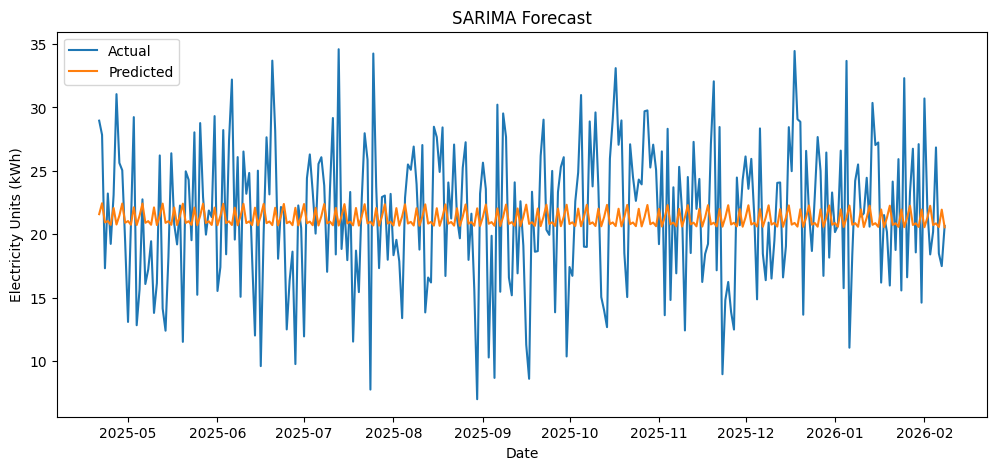

In [16]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, predictions, label="Predicted")

plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Electricity Units (kWh)")
plt.legend()

plt.show()

In [17]:
results = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae],
    "MSE": [mse],
    "RMSE": [rmse]
})

results.to_csv("sarima_results.csv", index=False)

In [18]:
import pickle

with open("sarima.pkl", "wb") as f:
    pickle.dump(model_fit, f)

In [19]:
from google.colab import files

files.download("sarima.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>